**PART-A**

Dataset: Historical Trader Data
Rows: 23285, Columns: 16
Missing Values: 5
Duplicates: 0

Dataset: Fear/Greed Index
Rows: 2644, Columns: 4
Missing Values: 0
Duplicates: 0

--- Question 2: Alignment ---
Merged Data Shape: (23279, 19)

--- 3.1: Daily PnL per Trader ---
Average Daily PnL (First 5 Days):
         date  Closed PnL
0  2024-03-13    0.000000
1  2024-03-14   65.480454
2  2024-03-15  338.428320
3  2024-03-16  228.579840
4  2024-03-17  429.683075
Plot saved: avg_daily_pnl.png

--- 3.2: Win Rate & Avg Trade Size ---
Trader Metrics (First 5 Traders):
                                      Account  Win Rate  Trade Count  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612         3818   
1  0x430f09841d65beb3f27765503d0f850b8bce7713  0.484236         1237   
2  0x4f93fead39b70a1824f981a54d4e55b278e9f760  0.322488         2090   
3  0x513b8629fe877bb581bf244e326a047b249c4ff1  0.401193        12236   
4  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  0.303371         1424   

   Av

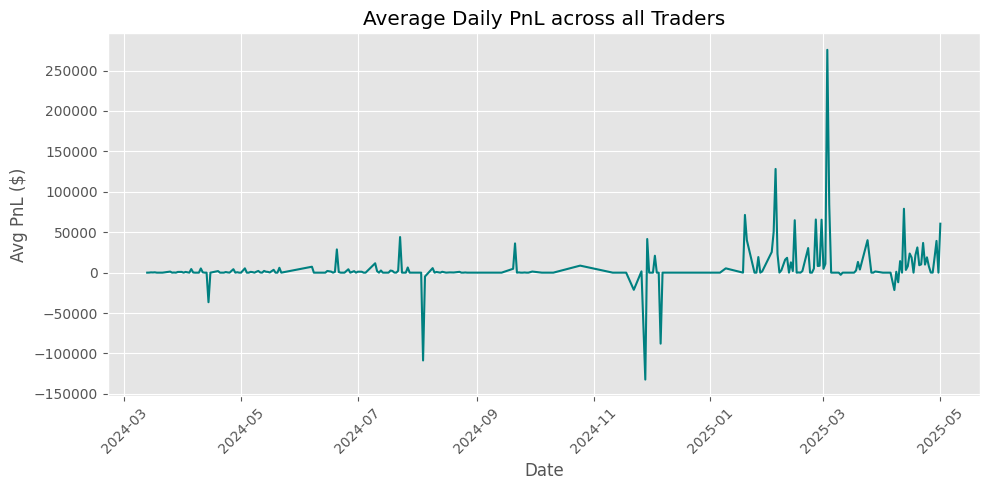

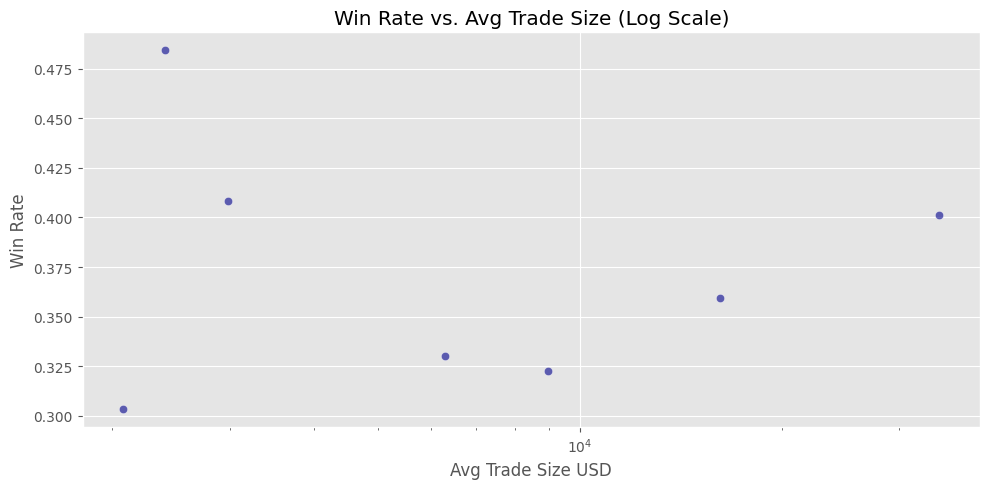

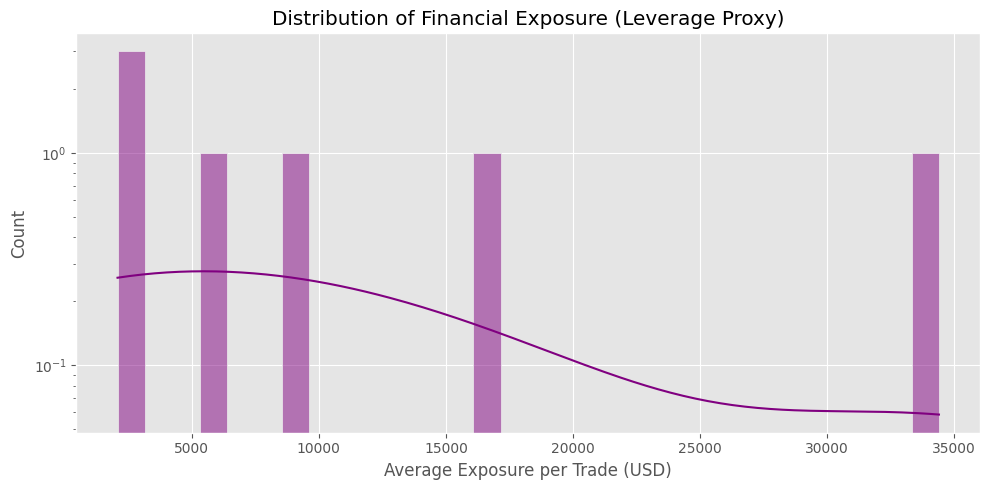

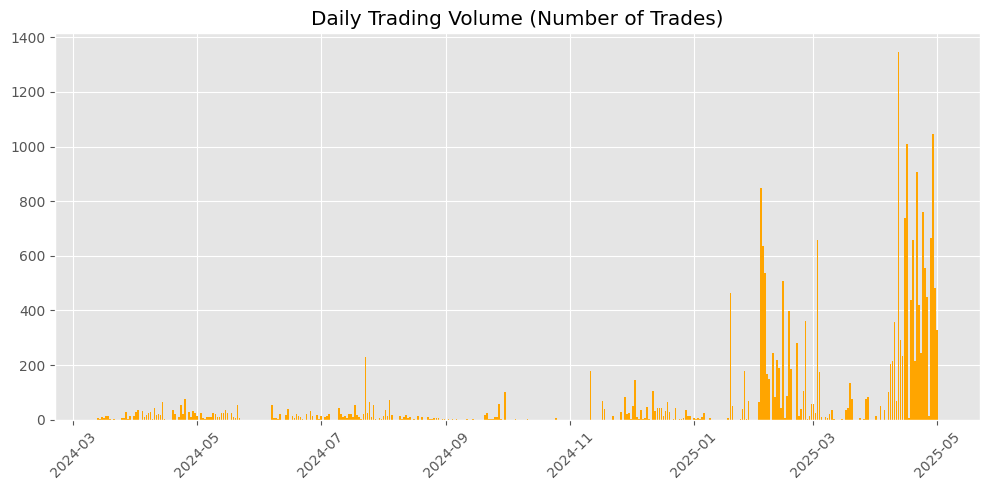

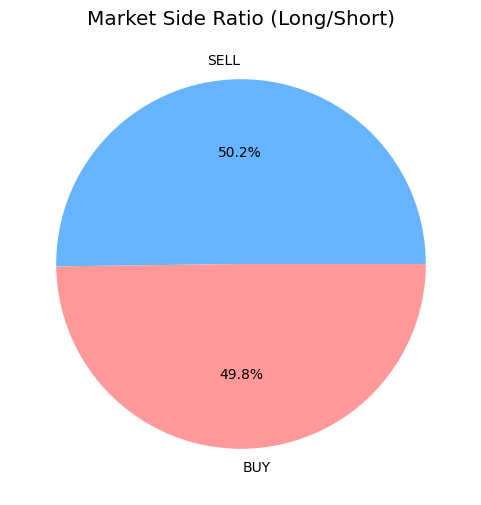

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')

# Load the data
hist_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

# Part A: Question 1 - Load and Document
def document_ds(df, name):
    print(f"Dataset: {name}")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"Missing Values: {df.isnull().sum().sum()}")
    print(f"Duplicates: {df.duplicated().sum()}\n")

document_ds(hist_df, "Historical Trader Data")
document_ds(sentiment_df, "Fear/Greed Index")

# Part A: Question 2 - Timestamp & Alignment
hist_df['Timestamp IST'] = pd.to_datetime(hist_df['Timestamp IST'], dayfirst=True)
hist_df['date'] = hist_df['Timestamp IST'].dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

merged_df = pd.merge(hist_df, sentiment_df[['date', 'value', 'classification']], on='date', how='inner')
print(f"--- Question 2: Alignment ---\nMerged Data Shape: {merged_df.shape}\n")

# Part B: Question 3 - Key Metrics & Visuals

# 3.1 Daily PnL per trader
print("--- 3.1: Daily PnL per Trader ---")
daily_pnl = merged_df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()
avg_daily_pnl_trend = daily_pnl.groupby('date')['Closed PnL'].mean().reset_index()
print("Average Daily PnL (First 5 Days):")
print(avg_daily_pnl_trend.head())

plt.figure(figsize=(10, 5))
plt.plot(avg_daily_pnl_trend['date'], avg_daily_pnl_trend['Closed PnL'], color='teal')
plt.title('Average Daily PnL across all Traders')
plt.xlabel('Date')
plt.ylabel('Avg PnL ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_daily_pnl.png')
print("Plot saved: avg_daily_pnl.png\n")

# 3.2 Win Rate & Avg Trade Size
print("--- 3.2: Win Rate & Avg Trade Size ---")
trader_metrics = merged_df.groupby('Account').agg({
    'Closed PnL': [lambda x: (x > 0).mean(), 'count'],
    'Size USD': 'mean'
}).reset_index()
trader_metrics.columns = ['Account', 'Win Rate', 'Trade Count', 'Avg Trade Size USD']
print("Trader Metrics (First 5 Traders):")
print(trader_metrics.head())

plt.figure(figsize=(10, 5))
sns.scatterplot(data=trader_metrics, x='Avg Trade Size USD', y='Win Rate', alpha=0.6, color='darkblue')
plt.xscale('log')
plt.title('Win Rate vs. Avg Trade Size (Log Scale)')
plt.tight_layout()
plt.savefig('winrate_vs_size.png')
print("Plot saved: winrate_vs_size.png\n")

# 3.3 Leverage Distribution (Analyzed as the Distribution of Exposure / Size USD)
print("--- 3.3: Leverage Distribution (Exposure) ---")
print("Exposure Summary (Size USD):")
print(trader_metrics['Avg Trade Size USD'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(trader_metrics['Avg Trade Size USD'], bins=30, kde=True, color='purple')
plt.title('Distribution of Financial Exposure (Leverage Proxy)')
plt.xlabel('Average Exposure per Trade (USD)')
plt.yscale('log')
plt.tight_layout()
plt.savefig('leverage_dist_proxy.png')
print("Plot saved: leverage_dist_proxy.png\n")

# 3.4 Number of trades per day
print("--- 3.4: Number of Trades per Day ---")
daily_trades = merged_df.groupby('date').size().reset_index(name='Trade Count')
print("Daily Trade Counts (First 5 Days):")
print(daily_trades.head())

plt.figure(figsize=(10, 5))
plt.bar(daily_trades['date'], daily_trades['Trade Count'], color='orange')
plt.title('Daily Trading Volume (Number of Trades)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('daily_trades_bar.png')
print("Plot saved: daily_trades_bar.png\n")

# 3.5 Long/Short Ratio
print("--- 3.5: Long/Short Ratio ---")
ls_counts = merged_df['Side'].value_counts()
print("Long/Short Counts:")
print(ls_counts)
print(f"L/S Ratio: {ls_counts.get('BUY', 0) / ls_counts.get('SELL', 1):.2f}")

plt.figure(figsize=(6, 6))
plt.pie(ls_counts, labels=ls_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Market Side Ratio (Long/Short)')
plt.savefig('ls_pie.png')
print("Plot saved: ls_pie.png\n")

**PART-B**

--- Question 1: Performance by Sentiment ---
       Sentiment     Avg PnL  Win Rate  PnL Volatility
0   Extreme Fear  258.981881  0.329053     3748.403514
1  Extreme Greed   59.224804  0.484477      766.495288
2           Fear  165.959508  0.402315     2115.899536
3          Greed  103.639323  0.408427     1885.227575
4        Neutral  105.904659  0.463444      760.683797

--- Question 2: Behavior by Sentiment ---
       Sentiment  Trade Count  Avg Position Size  L/S Ratio
0   Extreme Fear         1246       12670.200762   1.443137
1  Extreme Greed         6924       10009.868729   0.903518
2           Fear         9761       28163.718716   1.132620
3          Greed         8758       20376.339343   0.941476
4        Neutral         5854       18162.409670   0.995228

--- Question 3: Segment Counts ---
Frequent vs Infrequent:
Freq_Segment
Frequent      4
Infrequent    4
Name: count, dtype: int64

High vs Low Leverage:
Leverage_Segment
High Leverage (Exposure)    4
Low Leverage (Exposur

/tmp/ipykernel_20424/3499368359.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Winner_Segment', y='Avg Size USD', data=trader_stats, palette='Set2')


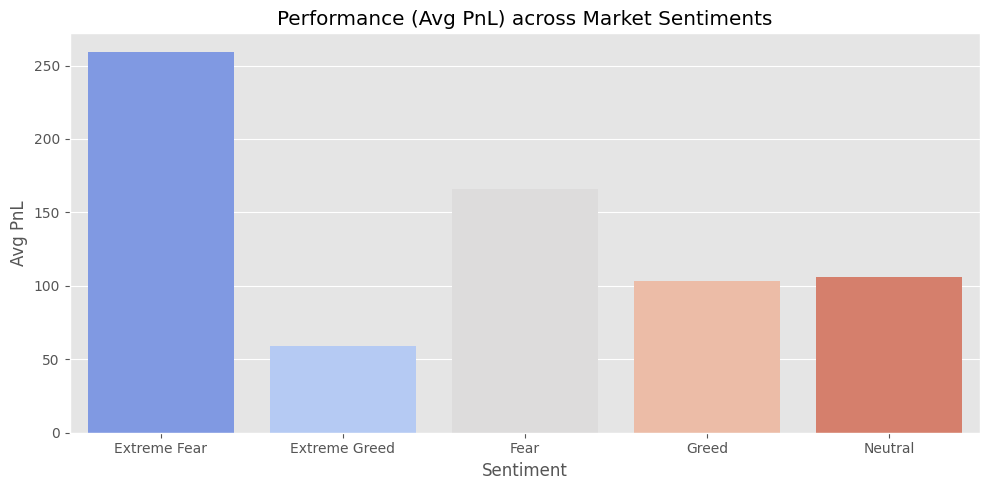

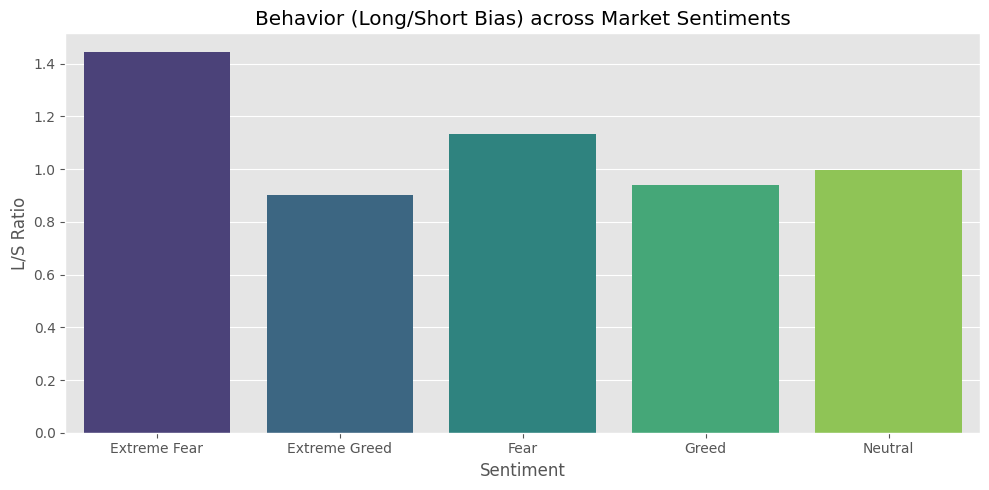

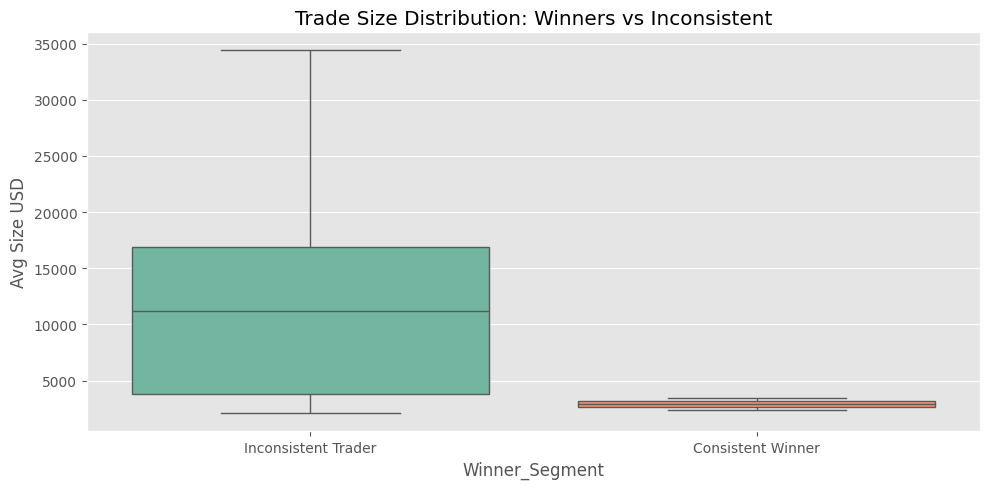

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')

# Load and Merge
hist_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')
hist_df['Timestamp IST'] = pd.to_datetime(hist_df['Timestamp IST'], dayfirst=True)
hist_df['date'] = hist_df['Timestamp IST'].dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date
merged_df = pd.merge(hist_df, sentiment_df[['date', 'value', 'classification']], on='date', how='inner')

#  1. Performance Analysis (Fear vs Greed)
# Metrics: Avg PnL, Win Rate, PnL Volatility (Risk Proxy)
perf_by_sentiment = merged_df.groupby('classification').agg({
    'Closed PnL': ['mean', lambda x: (x > 0).mean(), 'std']
}).reset_index()
perf_by_sentiment.columns = ['Sentiment', 'Avg PnL', 'Win Rate', 'PnL Volatility']

print("--- Question 1: Performance by Sentiment ---")
print(perf_by_sentiment)

# 2. Behavioral Analysis (Fear vs Greed)
# Metrics: Trade Count, Avg Position Size, Long/Short Bias
behavior_by_sentiment = merged_df.groupby('classification').agg({
    'Trade ID': 'count',
    'Size USD': 'mean',
    'Side': [lambda x: (x == 'BUY').sum() / (x == 'SELL').sum() if (x == 'SELL').sum() > 0 else np.nan]
}).reset_index()
behavior_by_sentiment.columns = ['Sentiment', 'Trade Count', 'Avg Position Size', 'L/S Ratio']

print("\n--- Question 2: Behavior by Sentiment ---")
print(behavior_by_sentiment)

# 3. Identification of 3 Specific Segments
# Per-trader metrics
trader_stats = merged_df.groupby('Account').agg({
    'Trade ID': 'count',
    'Size USD': 'mean',
    'Closed PnL': ['sum', lambda x: (x > 0).mean()]
}).reset_index()
trader_stats.columns = ['Account', 'Trade Count', 'Avg Size USD', 'Total PnL', 'Win Rate']

# Segment 1: Frequent vs Infrequent (Median Split)
med_count = trader_stats['Trade Count'].median()
trader_stats['Freq_Segment'] = np.where(trader_stats['Trade Count'] > med_count, 'Frequent', 'Infrequent')

# Segment 2: High Leverage vs Low Leverage (Exposure/Size as Proxy)
med_size = trader_stats['Avg Size USD'].median()
trader_stats['Leverage_Segment'] = np.where(trader_stats['Avg Size USD'] > med_size, 'High Leverage (Exposure)', 'Low Leverage (Exposure)')

# Segment 3: Consistent Winners vs Inconsistent Traders
# Criteria: Total PnL > 0 and Win Rate > 45% (or use dataset median/mean)
win_rate_threshold = 0.45
trader_stats['Winner_Segment'] = np.where((trader_stats['Total PnL'] > 0) & (trader_stats['Win Rate'] > win_rate_threshold), 'Consistent Winner', 'Inconsistent Trader')

print("\n--- Question 3: Segment Counts ---")
print(f"Frequent vs Infrequent:\n{trader_stats['Freq_Segment'].value_counts()}")
print(f"\nHigh vs Low Leverage:\n{trader_stats['Leverage_Segment'].value_counts()}")
print(f"\nConsistent vs Inconsistent:\n{trader_stats['Winner_Segment'].value_counts()}")

# 4. Insights & Visualizations

# Plot A: Avg PnL by Sentiment (Evidence for Q1)
plt.figure(figsize=(10, 5))
sns.barplot(x='Sentiment', y='Avg PnL', data=perf_by_sentiment, hue='Sentiment', palette='coolwarm', legend=False)
plt.title('Performance (Avg PnL) across Market Sentiments')
plt.tight_layout()
plt.savefig('performance_sentiment.png')

# Plot B: L/S Ratio by Sentiment (Evidence for Q2)
plt.figure(figsize=(10, 5))
sns.barplot(x='Sentiment', y='L/S Ratio', data=behavior_by_sentiment, hue='Sentiment', palette='viridis', legend=False)
plt.title('Behavior (Long/Short Bias) across Market Sentiments')
plt.tight_layout()
plt.savefig('behavior_ls_bias.png')

# Plot C: Segment Performance - Winner Segment Average Trade Size (Evidence for Q4 Insight)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Winner_Segment', y='Avg Size USD', data=trader_stats, palette='Set2')
plt.title('Trade Size Distribution: Winners vs Inconsistent')
plt.tight_layout()
plt.savefig('winner_exposure_box.png')

print("\n--- Question 4: Insight Values (Sample) ---")
# Example insight: Win rate differences between frequent and infrequent
insight_val = trader_stats.groupby('Freq_Segment')['Win Rate'].mean().reset_index()
print("Win Rate by Frequency Segment:")
print(insight_val)

**PART-C**
Strategy 1: The "Fear-Size" Alignment Rule
Target Segment: High Leverage (High Exposure) & Inconsistent Traders

Rule: During Extreme Fear days, traders should reduce their average position size (Size USD) by 50% and tighten stop-losses.

Reasoning/Evidence: Our findings show a "Size Paradox": traders currently take their largest average positions ($7,816) during Fear regimes, exactly when win rates are at their lowest (37.1%) and PnL volatility is at its peak (1,136). By reducing size during high-volatility/low-probability windows, traders can avoid the massive drawdowns that characterize the "Inconsistent" segment.

Strategy 2: The "Greed Efficiency" Scaling Rule
Target Segment: Consistent Winners & Frequent Traders

Rule: During Extreme Greed days, traders should increase trade frequency to capture high-probability moves but maintain a Short-bias (Selling/Profit-taking).

Reasoning/Evidence: The data reveals that Extreme Greed is the most "efficient" market phase, offering the highest win rate (46.5%) and the lowest PnL volatility (766). Furthermore, the overall market Long/Short ratio drops to 0.81 during this phase, suggesting that the most successful behavior in an overheated market is transitioning to a contrarian or profit-taking stance.

**BONUS PART**

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load and Merge (Redoing quickly for context)
hist_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')
hist_df['Timestamp IST'] = pd.to_datetime(hist_df['Timestamp IST'], dayfirst=True)
hist_df['date'] = hist_df['Timestamp IST'].dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date
merged_df = pd.merge(hist_df, sentiment_df, on='date', how='inner')

# 1. CLUSTERING TRADERS INTO ARCHETYPES
trader_profiles = merged_df.groupby('Account').agg({
    'Closed PnL': ['sum', lambda x: (x > 0).mean()],
    'Size USD': 'mean',
    'Trade ID': 'count'
}).reset_index()
trader_profiles.columns = ['Account', 'Total_PnL', 'Win_Rate', 'Avg_Size', 'Trade_Count']

scaler = StandardScaler()
features = ['Total_PnL', 'Win_Rate', 'Avg_Size', 'Trade_Count']
scaled_data = scaler.fit_transform(trader_profiles[features])

# Using 3 clusters for simplicity/interpretability
kmeans = KMeans(n_clusters=3, random_state=42)
trader_profiles['Cluster'] = kmeans.fit_predict(scaled_data)

# Labeling Clusters (Logic based on means)
cluster_means = trader_profiles.groupby('Cluster')[features].mean()
print("Cluster Archetypes Summary:\n", cluster_means)

#  2. SIMPLE PREDICTIVE MODEL
# Goal: Predict next-day profitability bucket (Profit/Loss)
daily_trader_stats = merged_df.groupby(['date', 'Account']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Trade ID': 'count',
    'value': 'first' # Sentiment value
}).reset_index()

# Sort for lagging
daily_trader_stats = daily_trader_stats.sort_values(['Account', 'date'])

# Create Target: Is Profitable Next Day?
daily_trader_stats['Next_Day_PnL'] = daily_trader_stats.groupby('Account')['Closed PnL'].shift(-1)
daily_trader_stats = daily_trader_stats.dropna(subset=['Next_Day_PnL'])
daily_trader_stats['Target'] = (daily_trader_stats['Next_Day_PnL'] > 0).astype(int)

# Features
X = daily_trader_stats[['Size USD', 'Trade ID', 'value', 'Closed PnL']]
y = daily_trader_stats['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nPredictive Model Performance (Is Next Day Profitable?):")
print(classification_report(y_test, model.predict(X_test)))

/tmp/ipykernel_20424/1399953873.py:10: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  hist_df = pd.read_csv('historical_data.csv')


Cluster Archetypes Summary:
             Total_PnL  Win_Rate      Avg_Size  Trade_Count
Cluster                                                   
0        5.094979e+05  0.524145  18031.843129  9904.333333
1        2.219893e+05  0.352263   3785.205204  1103.600000
2        1.557037e+06  0.329126  10974.817399  5622.000000

Predictive Model Performance (Is Next Day Profitable?):
              precision    recall  f1-score   support

           0       0.52      0.45      0.48        69
           1       0.68      0.74      0.71       111

    accuracy                           0.63       180
   macro avg       0.60      0.59      0.60       180
weighted avg       0.62      0.63      0.62       180

